In [1]:
import cv2
import numpy as np
from src.utils import ingaas_processing as ip
from src.utils import scanner_processing as scp
from pathlib import Path
import tomlkit
import matplotlib.pyplot as plt
import scipy

resize = lambda x: cv2.resize(x, (x.shape[1], 766))
stretch = lambda x: ip.lin_stretch_img(x, 0.3, 99.7)
process = lambda x: stretch(resize(x))

In [2]:
datadir = Path("C://Users//jeppe//Desktop//Work Stuffs//Data Sets//LIPI_Paper//20260618_144430")
scanpath = list(datadir.glob("*.raw"))[0]
configpath = list(datadir.glob("*.toml"))[0]
calpath = "data/calibration.npz"

In [3]:
with configpath.open() as f:
    config = tomlkit.load(f)
speed = config["robot"]["speed"]/60 #mm/s
fps = config["camera"]["fps"] #frames/s
mod_freq = config["general"]["modulation_freq"]
pixel_pitch = 15/1000 #mm/pitch (image plane)

In [11]:
scan = scp.load_scan(scanpath,images=3000,cal_path=calpath, offset_images=3250)
peaks,valleys = scp.get_extrema_scan(scan, len(scan), skip=0, overlap=0, f_m=mod_freq, fps=fps)
frame_profile = scan.sum(axis=2)
print(np.unique(np.diff(peaks), return_counts=True))
print(np.unique(np.diff(valleys), return_counts=True))
print(np.unique(peaks-valleys))

Loading scan
Processing a .raw file
(3000, 512, 640)
Undistorting
(3000, 512, 640)
(array([6]), array([498], dtype=int64))
(array([6]), array([498], dtype=int64))
[-3]


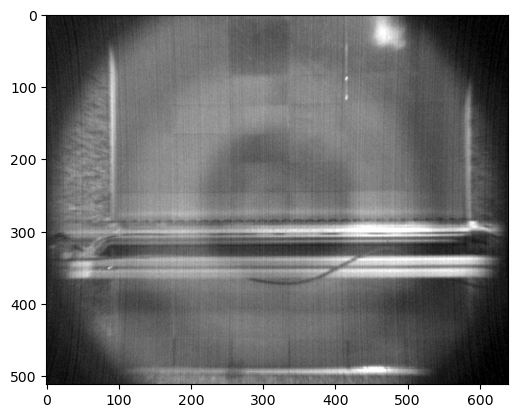

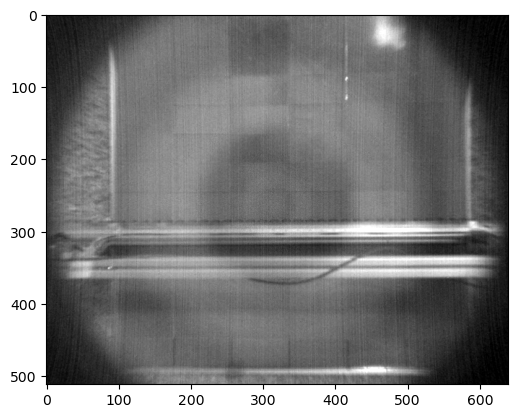

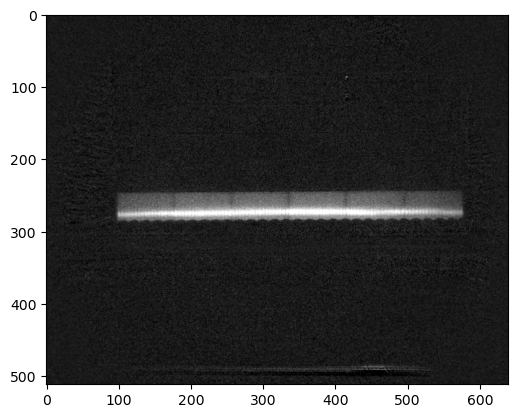

[[ 1.00000000e+00  3.77124353e-14 -1.28684695e-11]
 [-2.32666771e-15  1.00000000e+00 -3.80562709e-12]
 [-6.90570369e-18  3.35018387e-17  1.00000000e+00]]


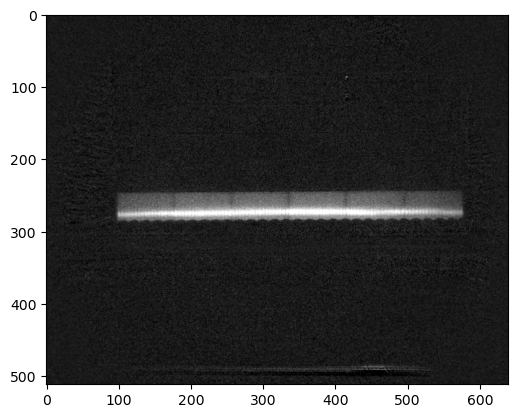

In [40]:
index = 200
signal = scan[peaks[index]]
bg = scan[valleys[index]]

plt.imshow(stretch(signal), cmap="gray")
plt.show()

plt.imshow(stretch(bg), cmap="gray")
plt.show()

plt.imshow(stretch(signal-bg), cmap="gray")
plt.show()

# 3. Find keypoints and descriptors using ORB
orb = cv2.ORB_create(1000)
kp, desc = orb.detectAndCompute(cv2.normalize(bg, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8), None)
kp_ref, desc_ref = orb.detectAndCompute(cv2.normalize(signal, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8), None)

# 4. Match features using Hamming distance
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = sorted(matcher.match(desc, desc_ref), key=lambda x: x.distance)

# 5. Filter out the top 20% of best matches
good_matches = matches[:int(len(matches) * 0.20)]
points = np.float32([kp[m.queryIdx].pt for m in good_matches])
points_ref = np.float32([kp_ref[m.trainIdx].pt for m in good_matches])

# 6. Compute Homography matrix and warp the image
h, mask = cv2.findHomography(points, points_ref, cv2.RANSAC)
height, width = signal.shape
print(h)
bg_trans = cv2.warpPerspective(bg, h, (width, height))

# 7. Save the final aligned output
plt.imshow(stretch(signal-bg_trans), cmap="gray")

